# Breakdown/Order:
1. Tiling 
- If working with orthomosaics use the orthomasic tiling script at the bottom
- If working with batches of images use tiling script for folders of images

2. Label/Create dataset
- Open new terminal and open label Img then goto open directory and change svaved directory to start labeling (MAKE SURE ITS YOLO MODE)
- Just one script where you put path labeled tiles + the folder you want the assorted dataset to goto

3. Train model (if neccesary)
- Get path of folder you want to train/test model with
- Determine path names and run naems you want to use
- Use the script that says TRAIN YOLO MODEL

4. Test model
- Use testing script
- Ensure the correct weights and folder paths are used for source of tiles you would like to test on
- (There is also a labeled script if you want to test on smaller random batch of tiles)

# Important Notes about expanding datasets
1. Fix false positives:
- Create folder of false positive tiles
- Ask any AI model: 
    - Input the current data set and what you want to add
    - Create empty text files in here for each photo
    - Ask it to combine both false positive folder and old dataset into one folder

2. Training model with new batch of images:
- Create folder of tiles you want to train and label
- Open labelIMG and open that directory to the new folder
    - Label and save
- Ask any AI model:
    - Input the current data set and what you want to add
    - Ask it to combine both the new folder and old dataset into one folder

# Slicing Photos into 640 by 640

In [ ]:
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
from PIL import Image
from rasterio.windows import Window

# --- SETTINGS ---
IMAGE_PATH = Path("260524_184730_155.jpg") # INSERT IMAGE PATH HERE!!!!
TILE_SIZE = 640                  # width and height of each small square (tile) in pixels
OVERLAP_RATIO = 0.25             # 25% overlap means tiles will share 160 pixels of edges
STRIDE = int(TILE_SIZE * (1 - OVERLAP_RATIO))   # Sliding over before making a new tile (480 px)
TILES_DIR = Path("tiles_155")    # PUT FOLDER YOU WANT TO SAVE TILES TO HERE

# --- OPEN IMAGE & BUILD TILE GRID ---
def sliding_window_positions(width, height, tile_size, stride):
    """
    This function calculates the (X, Y) starting coordinates for every tile 
    needed to cover the entire image.
    """
    # Create a list of X (horizontal) coordinates across the image width
    xs = list(range(0, width - tile_size + 1, stride))
    # Create a list of Y (vertical) coordinates down the image height
    ys = list(range(0, height - tile_size + 1, stride))
    
    # Make sure we grab the very edge/end of the image so nothing gets cut off
    xs.append(width - tile_size)
    ys.append(height - tile_size)
    
    positions, seen = [], set()
    # Loop through the grid coordinates and pair every X with every Y
    for row_off in ys:
        for col_off in xs:
            # Avoid duplicate coordinates (which can happen because of the .append lines above)
            if (col_off, row_off) not in seen:
                seen.add((col_off, row_off))
                positions.append((col_off, row_off))
                
    # Sort the positions so they go from top-to-bottom, left-to-right
    return sorted(positions, key=lambda p: (p[1], p[0]))

if TILES_DIR.exists():
    shutil.rmtree(TILES_DIR)
# Create the new empty output folder
TILES_DIR.mkdir()

records = [] # This empty list will hold information about each tile to make a spreadsheet later

# Open the main image file using the rasterio library
with rasterio.open(IMAGE_PATH) as src:
    print(f"Image: {src.width} x {src.height}")
    
    # Call our function above to get all the (X, Y) crop coordinates
    positions = sliding_window_positions(src.width, src.height, TILE_SIZE, STRIDE)
    print(f"Tiles: {len(positions)}  |  Tile size: {TILE_SIZE}  |  Stride: {STRIDE}")

    # Loop through every coordinate pair to slice the image
    for tile_id, (col_off, row_off) in enumerate(positions):
        
        # Window() tells rasterio exactly where to look: (Start X, Start Y, Width, Height)
        # src.read() physically extracts just that specific "window" from the big image
        tile_bands = src.read(window=Window(col_off, row_off, TILE_SIZE, TILE_SIZE))
        
        # Re-arrange the image data array from (Channels, Height, Width) to (Height, Width, Channels) 
        rgb = np.moveaxis(tile_bands[:3], 0, -1).astype(np.uint8)

        # Create a unique filename for the tile using its ID and coordinates
        out_name = f"tile_{tile_id:04d}_x{col_off}_y{row_off}.jpg"
        
        # Turn the raw data array into a JPEG image and save it to your folder
        Image.fromarray(rgb).save(TILES_DIR / out_name, format="JPEG", quality=95)

        # Save the tile's data to our records list
        records.append({
            "tile_id": tile_id,
            "filename": out_name,
            "col_off": col_off, # The X coordinate where the slice started
            "row_off": row_off, # The Y coordinate where the slice started
        })

tiles_df = pd.DataFrame(records)
manifest = TILES_DIR / "tile_manifest_640.csv"
tiles_df.to_csv(manifest, index=False)

print(f"Saved {len(tiles_df)} tiles to {TILES_DIR.resolve()}")
print(f"Manifest: {manifest.resolve()}")
tiles_df.head()

# Formulating dataset (USE AFTER LABELING ON LABELIMG)

## Comments show where to put desired file paths for tiles and dataset

In [ ]:
import random
import shutil
from pathlib import Path

# Folders of sliced tiles and datasets
TILES = Path(r"C:\Users\lesli\Desktop\birdproject\tiles_640") # PUT FOLDER OF LABELED TILES HERE
DATASET = Path(r"C:\Users\lesli\Desktop\birdproject\dataset") # FOLDER YOU WANT TRAINING/VAL TILES TO GO TO

# Find every label file (skip classes.txt)
labeled = [p for p in TILES.glob("*.txt") if p.name != "classes.txt"]
labeled = sorted(labeled)

# seed' ensures that the "random" shuffle happens for the validation/training
random.seed(42)
random.shuffle(labeled)

# split data math: 0.8 means 80% goes to training, 20% to validation.
split = int(len(labeled) * 0.8)
train_labels = labeled[:split]
val_labels = labeled[split:]

# Fresh directory set up
if DATASET.exists():
    shutil.rmtree(DATASET)

# Distribution loop (Ran once for train set and once for label set)
for subset, labels in [("train", train_labels), ("val", val_labels)]:
    img_dir = DATASET / "images" / subset
    lbl_dir = DATASET / "labels" / subset

    # Ensures proper allocation of folders
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)

    for lbl in labels:
        jpg = TILES / f"{lbl.stem}.jpg"
        if not jpg.exists():
            print("Missing image for", lbl.name)
            continue
        shutil.copy2(jpg, img_dir / jpg.name)
        shutil.copy2(lbl, lbl_dir / lbl.name)

print(f"Labeled tiles: {len(labeled)}")
print(f"Train: {len(train_labels)}")
print(f"Val:   {len(val_labels)}")
print(f"Dataset folder: {DATASET.resolve()}")

# Train YOLO Model

## In the comments see where to change model name

In [ ]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
from pathlib import Path
import torch
torch.set_num_threads(1)
from ultralytics import settings, YOLO
settings.update({"sync": False})
model = YOLO("yolov8n.pt")
results = model.train(
    data="birds.yaml",       # two classes: whitebird (0) + brownbird (1)
    epochs=40,
    imgsz=416,
    batch=1,
    workers=0,
    device="cpu",
    amp=False,
    mosaic=0.0,
    plots=False,
    cache=False,
    name="superbird_v3", # Change to name of the model you want to train 
    exist_ok=True,
    patience=10,
    verbose=True,
)
print("Best weights:", Path(results.save_dir) / "weights" / "best.pt")

# Test YOLO Model on Validation Folder

In [ ]:
from pathlib import Path
from ultralytics import YOLO

RUN_NAME = "superbird_v3" # What you want your run name to be
WEIGHTS = Path(f"runs/detect/{RUN_NAME}/weights/best.pt") # Make sure this is the path to the latest weights of the model you want to test
assert WEIGHTS.exists(), f"Train first — missing {WEIGHTS}"

model = YOLO(str(WEIGHTS))
pred = model.predict(
    source="dataset/images/val", # Path of what tiles you want to test on
    conf=0.35,        # lower (e.g. 0.25) if birds are missed; higher if false positives
    iou=0.30,         # overlap threshold — helps reduce double boxes
    max_det=10,
    imgsz=416,
    save=True,
    name=f"{RUN_NAME}_test",
)

print("Predictions saved to:", pred[0].save_dir)

In [3]:
!python save_annotated_tiles.py --weights runs/detect/birds_v2/weights/best.pt --output annotated_tiles_with_coords

Saved 166 images to C:\Users\lesli\Desktop\birdproject\annotated_tiles_with_coords


In [12]:
import pandas as pd

df = pd.read_csv("bird_detections.csv")
print(f"{len(df)} birds detected")
df.head(20)

355 birds detected


,bird_id,species,class_id,confidence,tile,tile_col_off,tile_row_off,tile_x1,tile_y1,tile_x2,tile_y2,pixel_x_full,pixel_y_full,latitude,longitude,camera_altitude_m
0,0,whitebird,1,0.6915,tile_0007_x3360_y0.jpg,3360,0,568.0,412.8,640.0,508.0,3964.0,460.4,21.458690,-157.724350,96.033
1,1,whitebird,1,0.5722,tile_0007_x3360_y0.jpg,3360,0,349.9,236.3,421.4,344.8,3745.6,290.6,21.458713,-157.724382,96.033
2,2,whitebird,1,0.9414,tile_0008_x3840_y0.jpg,3840,0,82.5,416.1,243.4,507.5,4003.0,461.8,21.458689,-157.724344,96.033
3,3,brownbird,0,0.9863,tile_0012_x5760_y0.jpg,5760,0,454.5,429.6,554.7,552.7,6264.6,491.2,21.458685,-157.724014,96.033
4,4,brownbird,0,0.9357,tile_0013_x6240_y0.jpg,6240,0,0.0,438.3,80.4,559.0,6280.2,498.6,21.458684,-157.724012,96.033
5,5,whitebird,1,0.9233,tile_0027_x3360_y480.jpg,3360,480,448.2,395.7,575.9,473.6,3872.1,914.7,21.458628,-157.724363,96.033
6,6,whitebird,1,0.9065,tile_0027_x3360_y480.jpg,3360,480,249.0,387.7,364.2,481.1,3666.6,914.4,21.458628,-157.724393,96.033
7,7,brownbird,0,0.9993,tile_0028_x3840_y480.jpg,3840,480,310.1,331.6,454.1,441.8,4222.1,866.7,21.458634,-157.724312,96.033
8,8,whitebird,1,0.9073,tile_0028_x3840_y480.jpg,3840,480,0.6,394.3,95.2,474.7,3887.9,914.5,21.458628,-157.724361,96.033
9,9,whitebird,1,0.4030,tile_0028_x3840_y480.jpg,3840,480,141.0,0.6,246.2,25.8,4033.6,493.2,21.458685,-157.724340,96.033


In [4]:
# Save all annotated tiles — YOLO validation-style boxes (no yellow)
import os
from pathlib import Path
out = Path("annotated_tiles_with_coords").resolve()
print("Folder:", out)
os.startfile(str(out))

Folder: C:\Users\lesli\Desktop\birdproject\annotated_tiles_with_coords


In [7]:
!python plot_on_original.py

Plotted 219 birds (ground-truth labels) — removed 154 duplicates from overlap
Full size: C:\Users\lesli\Desktop\birdproject\original_with_birds.jpg  (9504x6336)
Preview:   C:\Users\lesli\Desktop\birdproject\original_with_birds_preview.jpg


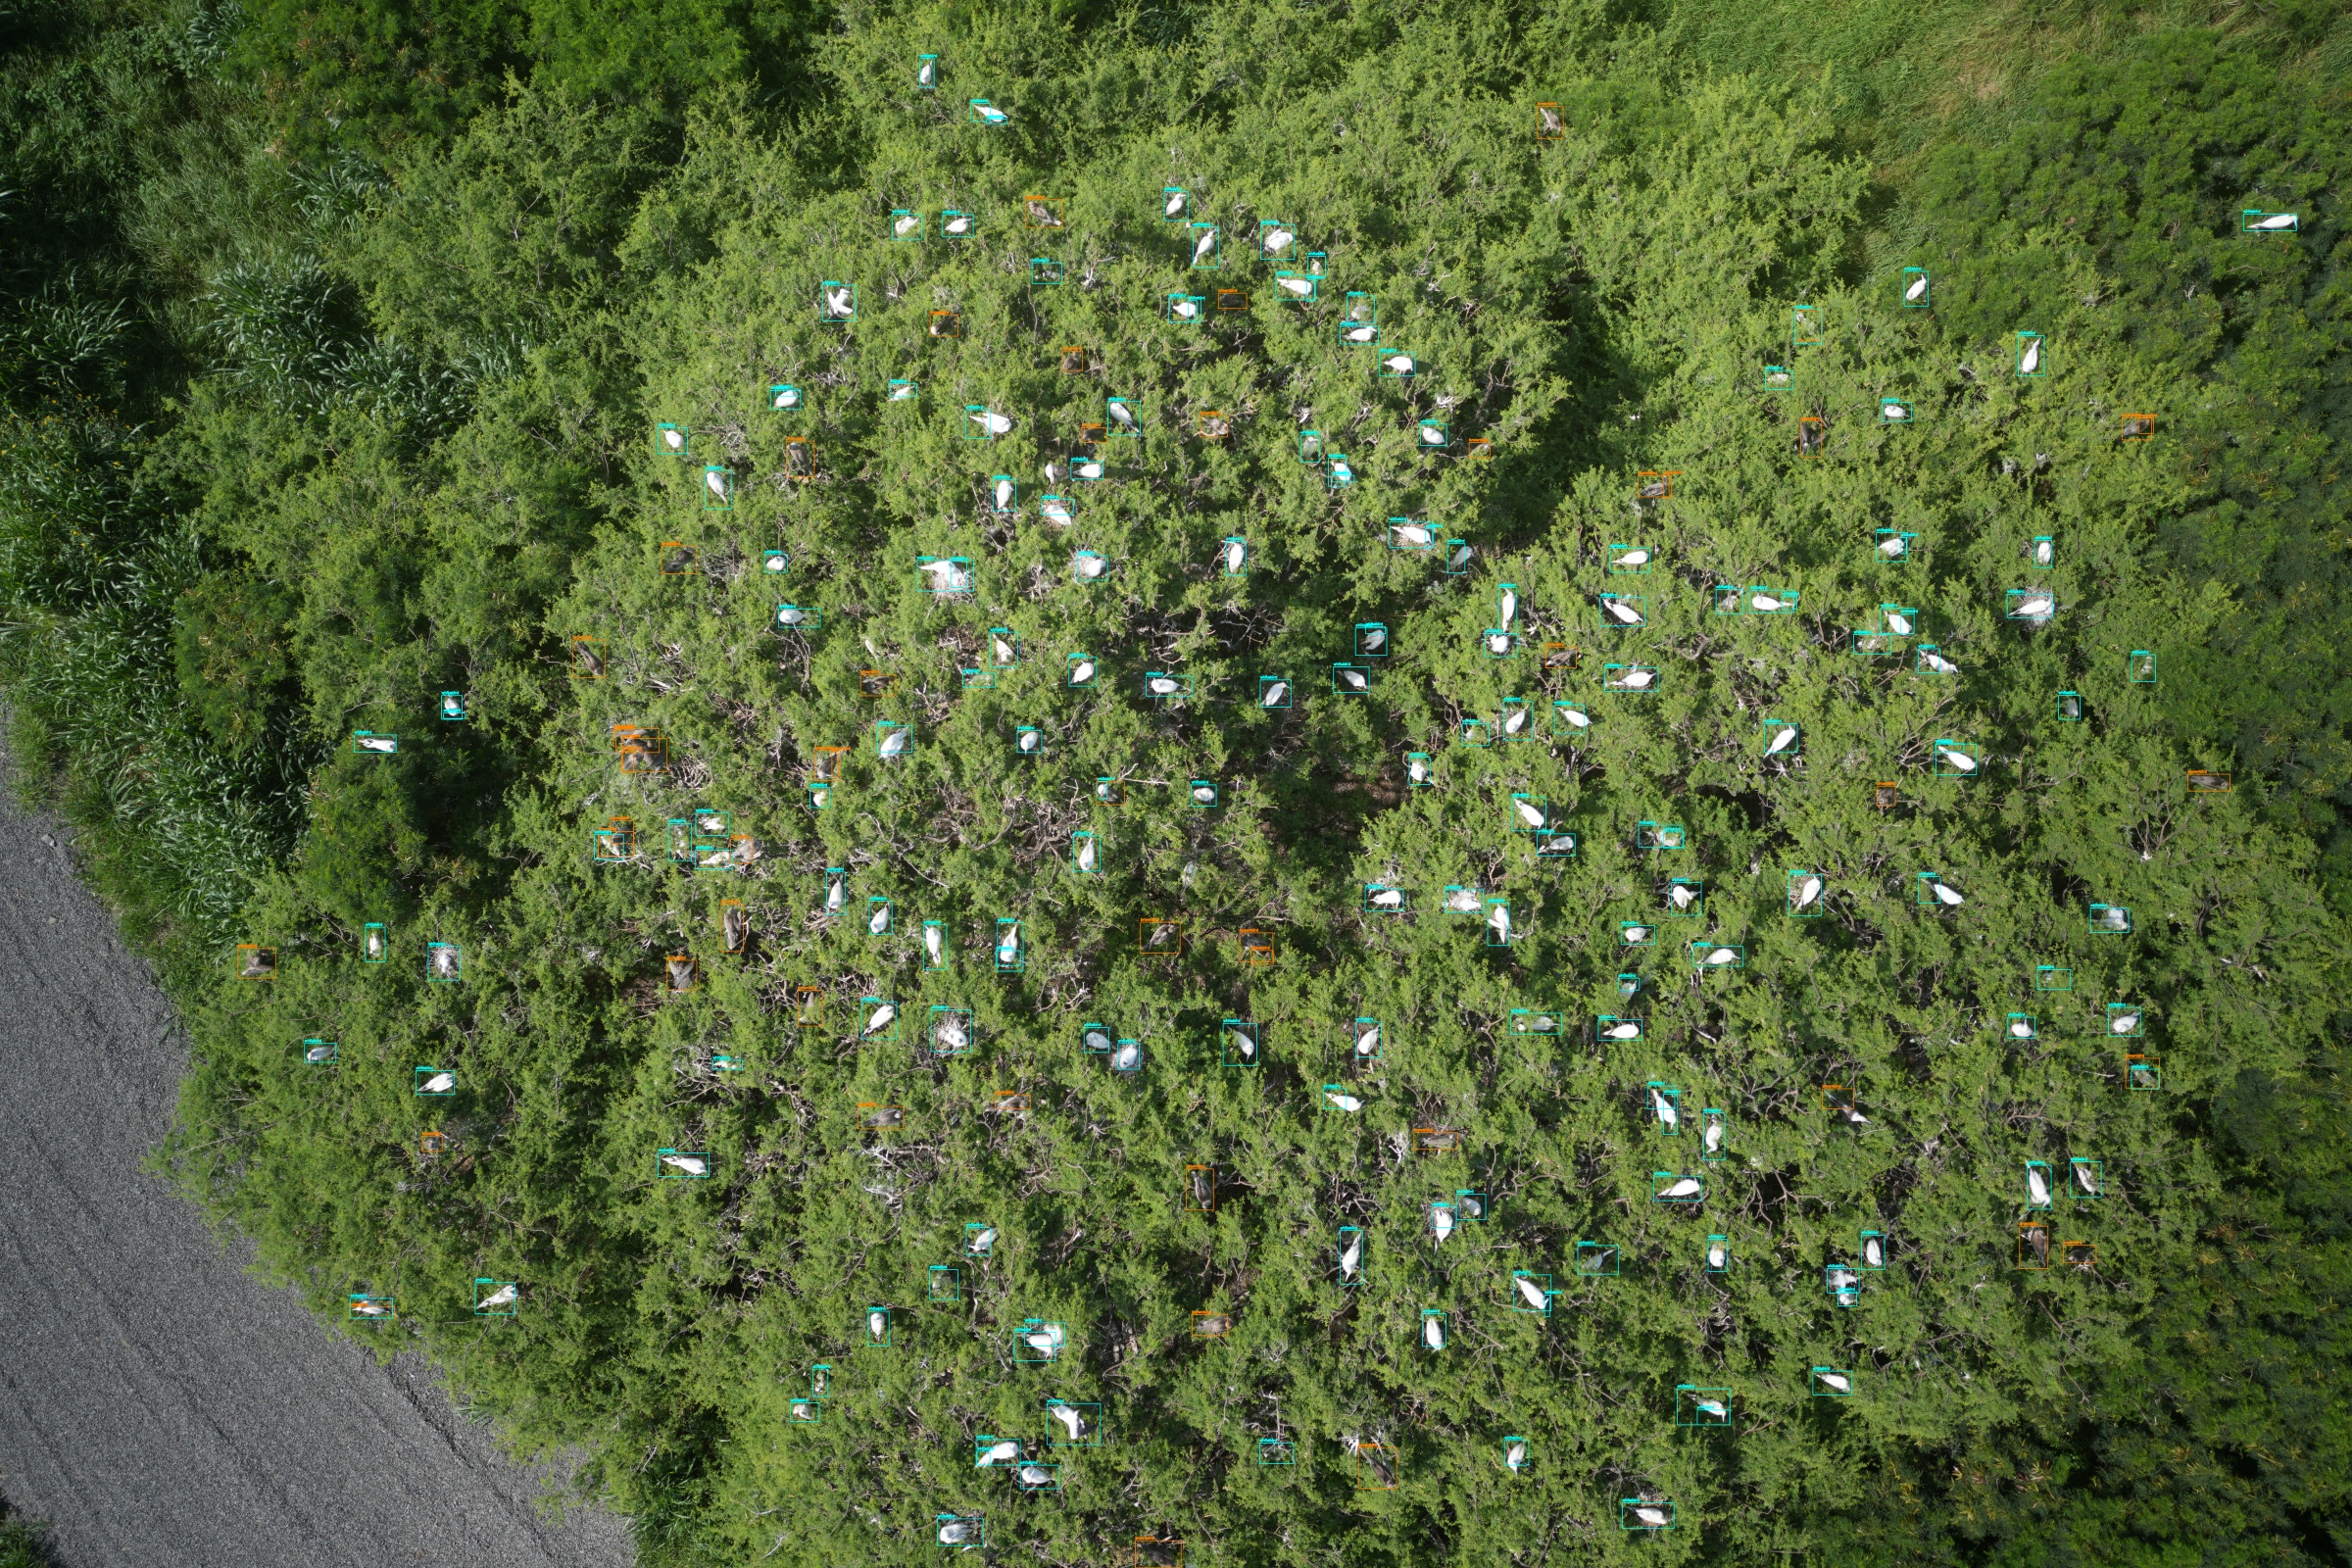

Full-size file: original_with_birds.jpg


In [8]:
from IPython.display import Image, display
display(Image(filename="original_with_birds_preview.jpg", width=900))
print("Full-size file: original_with_birds.jpg")


# Script to get rid of large folder of overlapping distance

In [ ]:
# Select non-overlapping drone images (GPS + geodesic, MIN_DISTANCE = 15.9 m)
import os
import shutil
from pathlib import Path

import pandas as pd
from exif import Image
from geopy.distance import geodesic
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
SOURCE_DIRS = [
    Path("D:\Astor_Bird_30_Optical_A"), # Path to folders of images (1)
    Path("D:\Astor_Bird_30_Optical_B"), # Path to folder of images (2)
]
OUTPUT_DIR = Path("selected_images_30m") # Path to where you want selected iamges to go
MIN_DISTANCE_METERS = 15.9


def dms_to_dd(coords, ref):
    """Convert Degrees/Minutes/Seconds to Decimal Degrees."""
    degrees, minutes, seconds = coords
    dd = degrees + (minutes / 60.0) + (seconds / 3600.0)
    if ref in ["S", "W"]:
        dd = -dd
    return dd


def get_image_location(image_path):
    """Extract latitude and longitude from image EXIF data."""
    with open(image_path, "rb") as img_file:
        img = Image(img_file)
        if not img.has_exif:
            return None
        try:
            lat = dms_to_dd(img.gps_latitude, img.gps_latitude_ref)
            lon = dms_to_dd(img.gps_longitude, img.gps_longitude_ref)
            return (lat, lon)
        except AttributeError:
            return None


OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

images = []
for folder in SOURCE_DIRS:
    if not folder.exists():
        print("MISSING:", folder.resolve())
        continue
    for name in sorted(os.listdir(folder)):
        if name.lower().endswith((".jpg", ".jpeg", ".png")):
            images.append(folder / name)

if not images:
    raise FileNotFoundError("No images found. Check SOURCE_DIRS paths.")

print(f"Min distance between kept photos: {MIN_DISTANCE_METERS} m")
print(f"Scanning {len(images)} images...\n")

last_coords = None
copied_count = 0
all_rows = []
selected_rows = []

for img_path in images:
    current_coords = get_image_location(img_path)

    if current_coords is None:
        print(f"Skipping {img_path.name}: No GPS data found.")
        continue

    lat, lon = current_coords
    row = {
        "path": str(img_path),
        "filename": img_path.name,
        "folder": img_path.parent.name,
        "latitude": lat,
        "longitude": lon,
    }
    all_rows.append(row)

    if last_coords is None or geodesic(last_coords, current_coords).meters >= MIN_DISTANCE_METERS:
        dst_name = f"{img_path.parent.name}__{img_path.name}"
        shutil.copy2(img_path, OUTPUT_DIR / dst_name)
        last_coords = current_coords
        copied_count += 1
        selected_rows.append(row)
        print(f"Selected: {img_path.parent.name}/{img_path.name}")

pd.DataFrame(all_rows).to_csv("all_drone_gps.csv", index=False)
pd.DataFrame(selected_rows).to_csv("selected_drone_images.csv", index=False)

print(f"\nDone! Selected {copied_count} out of {len(images)} images.")
print("Copied to:", OUTPUT_DIR.resolve())

# Plot all GPS vs selected
all_df = pd.DataFrame(all_rows)
sel_df = pd.DataFrame(selected_rows)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(all_df["longitude"], all_df["latitude"], s=8, alpha=0.25, label="all photos")
ax.scatter(sel_df["longitude"], sel_df["latitude"], s=28, label="selected")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("West Mokapu Point — GPS spatial filtering (15.9 m)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

sel_df.head()

# Tiling Script for fodlers of images (batches of images at once)

In [ ]:
# Tile EVERY photo in selected_images_30m/ → tiles_selected_30m/
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import rasterio
from rasterio.windows import Window
SOURCE_DIR = Path("selected_images_30")   # folder of selected full photos
TILES_DIR = Path("tiles_selected_30m")     # all tiles from all photos go PICK YOUR PATH
TILE_SIZE = 640
OVERLAP_RATIO = 0.25
STRIDE = int(TILE_SIZE * (1 - OVERLAP_RATIO))  # 480
TILES_DIR.mkdir(parents=True, exist_ok=True)
def sliding_window_positions(width, height, tile_size, stride):
    xs = list(range(0, width - tile_size + 1, stride))
    ys = list(range(0, height - tile_size + 1, stride))
    # make sure right/bottom edges are covered
    if not xs or xs[-1] != width - tile_size:
        xs.append(width - tile_size)
    if not ys or ys[-1] != height - tile_size:
        ys.append(height - tile_size)
    # unique + sorted
    xs = sorted(set(max(0, x) for x in xs))
    ys = sorted(set(max(0, y) for y in ys))
    return [(x, y) for y in ys for x in xs]
images = sorted(
    list(SOURCE_DIR.glob("*.jpg"))
    + list(SOURCE_DIR.glob("*.JPG"))
    + list(SOURCE_DIR.glob("*.jpeg"))
    + list(SOURCE_DIR.glob("*.JPEG"))
)
if not images:
    raise FileNotFoundError(f"No images in {SOURCE_DIR.resolve()}")
records = []
total_tiles = 0
for img_path in images:
    stem = img_path.stem  # unique-ish name already (folder__filename)
    with rasterio.open(img_path) as src:
        positions = sliding_window_positions(src.width, src.height, TILE_SIZE, STRIDE)
        for tile_id, (col_off, row_off) in enumerate(positions):
            # skip if window would go out of bounds
            if col_off + TILE_SIZE > src.width or row_off + TILE_SIZE > src.height:
                continue
            tile_bands = src.read(window=Window(col_off, row_off, TILE_SIZE, TILE_SIZE))
            rgb = np.moveaxis(tile_bands[:3], 0, -1).astype(np.uint8)
            # include source photo name so tiles from different images never collide
            out_name = f"{stem}__tile_{tile_id:04d}_x{col_off}_y{row_off}.jpg"
            out_path = TILES_DIR / out_name
            cv2.imwrite(str(out_path), cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR))
            records.append({
                "source_image": img_path.name,
                "tile_id": tile_id,
                "filename": out_name,
                "col_off": col_off,
                "row_off": row_off,
            })
            total_tiles += 1
    print(f"Tiled {img_path.name}: {len(positions)} tiles")
manifest = TILES_DIR / "tile_manifest.csv"
pd.DataFrame(records).to_csv(manifest, index=False)
print(f"\nDone. {len(images)} photos → {total_tiles} tiles")
print("Tiles folder:", TILES_DIR.resolve())
print("Manifest:", manifest.resolve())

# If you want to test on smaller sample sizes

In [ ]:
# Quick test: randomly sample a handful of tiles, then run SuperBird
import random
import shutil
from pathlib import Path
from ultralytics import YOLO

TILES_DIR = Path("tiles_selected_30m")   # your big tile folder
SAMPLE_DIR = Path("tiles_quick_test")    # small folder for this test
N_SAMPLE = 5000                            # try 30–100 for a quick look
RUN_NAME = "superbird_v3"                # your latest model
SEED = 42

WEIGHTS = Path(f"runs/detect/{RUN_NAME}/weights/best.pt")
assert WEIGHTS.exists(), f"Missing {WEIGHTS}"

all_tiles = sorted(TILES_DIR.glob("*.jpg"))
print(f"Total tiles available: {len(all_tiles)}")

random.seed(SEED)
sample = random.sample(all_tiles, min(N_SAMPLE, len(all_tiles)))

# fresh sample folder
if SAMPLE_DIR.exists():
    shutil.rmtree(SAMPLE_DIR)
SAMPLE_DIR.mkdir()

for t in sample:
    shutil.copy2(t, SAMPLE_DIR / t.name)

print(f"Copied {len(sample)} tiles to {SAMPLE_DIR.resolve()}")

model = YOLO(str(WEIGHTS))
pred = model.predict(
    source=str(SAMPLE_DIR),
    conf=0.35,
    iou=0.30,
    max_det=10,
    imgsz=416,
    save=True,
    name=f"{RUN_NAME}_quick_test",
)

print("Results:", pred[0].save_dir)

# open results folder (Windows)
import os
os.startfile(str(pred[0].save_dir))

# ORTHOMOSAIC TILING

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import rasterio
from rasterio.windows import Window

MOSAIC = Path(r"C:\Users\lesli\Desktop\birdproject\Mokapu_SamllSite_transparent_mosaic_group1.tif") # Path of orthomosaic file
TILES_DIR = Path("tiles_ortho") # Path to folder where you want tiles to go
TILE_SIZE = 640
OVERLAP_RATIO = 0.25
STRIDE = int(TILE_SIZE * (1 - OVERLAP_RATIO))

TILES_DIR.mkdir(parents=True, exist_ok=True)

if not MOSAIC.exists():
    raise FileNotFoundError(f"Mosaic not found: {MOSAIC.resolve()}")

def sliding_window_positions(width, height, tile_size, stride):
    xs = list(range(0, width - tile_size + 1, stride))
    ys = list(range(0, height - tile_size + 1, stride))
    if not xs or xs[-1] != width - tile_size:
        xs.append(width - tile_size)
    if not ys or ys[-1] != height - tile_size:
        ys.append(height - tile_size)
    xs = sorted(set(max(0, x) for x in xs))
    ys = sorted(set(max(0, y) for y in ys))
    return [(x, y) for y in ys for x in xs]

records = []
total_tiles = 0
stem = MOSAIC.stem

with rasterio.open(MOSAIC) as src:
    print(f"Opening {MOSAIC.name}: {src.width}x{src.height}, {src.count} bands")
    positions = sliding_window_positions(src.width, src.height, TILE_SIZE, STRIDE)
    for tile_id, (col_off, row_off) in enumerate(positions):
        if col_off + TILE_SIZE > src.width or row_off + TILE_SIZE > src.height:
            continue
        tile_bands = src.read(window=Window(col_off, row_off, TILE_SIZE, TILE_SIZE))
        rgb = np.moveaxis(tile_bands[:3], 0, -1)
        if rgb.dtype != np.uint8:
            rgb = np.clip(rgb.astype(np.float32) / max(float(np.nanmax(rgb)), 1) * 255, 0, 255).astype(np.uint8)
        out_name = f"{stem}__tile_{tile_id:04d}_x{col_off}_y{row_off}.jpg"
        cv2.imwrite(str(TILES_DIR / out_name), cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR))
        records.append({
            "source_image": MOSAIC.name,
            "tile_id": tile_id,
            "filename": out_name,
            "col_off": col_off,
            "row_off": row_off,
        })
        total_tiles += 1
        if total_tiles % 500 == 0:
            print(f"  saved {total_tiles} tiles...")

pd.DataFrame(records).to_csv(TILES_DIR / "tile_manifest.csv", index=False)
print(f"\nDone. {total_tiles} tiles")
print("Tiles folder:", TILES_DIR.resolve())